# Australian Fuel Market : Competitor Pricing Analysis
## Notebook 3: Repeatable Weekly Reporting Pipeline

The analysis in Notebook 2 were retrospective, they looked across the full historical dataset to understand patterns. This notebook builds something different: a **forward-facing, repeatable reporting function** that a pricing team could run every week to get a current snapshot of the market.

The pipeline takes a date range as input and produces three outputs:

1. **Market snapshot** — current average price by brand, the week-on-week change, and each brand's position relative to the market average
2. **Anomaly flags** — brands whose current price is more than 2 cpl outside their own 8-week rolling average, flagged as needing attention
3. **Plain-English briefing** — a paragraph summary formatted as if it were going to a non-technical pricing manager

---

**Input:** `data/processed/daily_brand_averages.parquet` (produced by Notebook 1)  
**Output:** Weekly report saved to `outputs/weekly_report_[date].txt` and chart to `outputs/weekly_report_[date].png`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

Path('outputs').mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.color':        '#EEEEEE',
    'grid.linewidth':    0.6,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'legend.frameon':    False,
})

BRAND_COLORS = {
    '7-Eleven':     '#007041',
    'Ampol':        '#E63329',
    'BP':           '#007A33',
    'Coles Express':'#E2001A',
    'Shell':        '#FFC72C',
    'United':       '#0057A8',
    'Puma':         '#1A1A1A',
    'Woolworths':   '#00833E',
    'Metro':        '#888888',
}

# Load data
df = pd.read_parquet('data/processed/daily_brand_averages.parquet')
df['date'] = pd.to_datetime(df['date'])

print(f"Data loaded. Coverage: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Brands available: {sorted(df['brand_clean'].unique())}")

Data loaded. Coverage: 2021-12-01 to 2025-05-31
Brands available: ['7-Eleven', 'Ampol', 'BP', 'Coles Express', 'Metro', 'Puma', 'Shell', 'United', 'Woolworths']


---
## Part 1 — Core Reporting Functions

Defined the pipeline as a set of modular functions. Each function does one job cleanly. This makes it easy to update individual components as requirements change for example, swapping in a different anomaly threshold or adding a new brand without touching the rest of the pipeline.

In [4]:
def get_weekly_snapshot(df, report_date, lookback_weeks=8):
    """
    For a given report_date, compute each brand's:
      - Average price in the most recent 7 days
      - Average price in the prior 7 days (for week-on-week change)
      - Rolling 8-week average (baseline for anomaly detection)
      - Position vs market average this week
      - Anomaly flag if current price deviates more than threshold from 8-week average

    Parameters
    ----------
    df           : daily brand averages dataframe
    report_date  : str or datetime — the end date of the reporting week (e.g. most recent Monday)
    lookback_weeks : int — how many weeks of history to use for the rolling baseline

    Returns
    -------
    snapshot : DataFrame with one row per brand
    """
    report_date = pd.to_datetime(report_date)

    # Define date windows
    week_start      = report_date - timedelta(days=6)
    prior_week_end  = report_date - timedelta(days=7)
    prior_week_start= report_date - timedelta(days=13)
    baseline_start  = report_date - timedelta(weeks=lookback_weeks)

    # Slice each window
    this_week  = df[(df['date'] >= week_start)    & (df['date'] <= report_date)]
    prior_week = df[(df['date'] >= prior_week_start) & (df['date'] <= prior_week_end)]
    baseline   = df[(df['date'] >= baseline_start)   & (df['date'] <= report_date)]

    # Average price per brand in each window
    this_avg  = this_week.groupby('brand_clean')['avg_price'].mean().rename('price_this_week')
    prior_avg = prior_week.groupby('brand_clean')['avg_price'].mean().rename('price_prior_week')
    base_avg  = baseline.groupby('brand_clean')['avg_price'].mean().rename('price_8wk_avg')

    snapshot = pd.concat([this_avg, prior_avg, base_avg], axis=1).round(1)

    # Week-on-week change
    snapshot['wow_change'] = (snapshot['price_this_week'] - snapshot['price_prior_week']).round(1)

    # Position vs market average this week
    market_avg_this_week = snapshot['price_this_week'].mean()
    snapshot['vs_market'] = (snapshot['price_this_week'] - market_avg_this_week).round(1)

    # Rank within market (1 = cheapest)
    snapshot['market_rank'] = snapshot['price_this_week'].rank(na_option='bottom').astype('Int64')

    # Anomaly flag — price more than 2 cpl outside 8-week average
    ANOMALY_THRESHOLD = 2.0
    snapshot['deviation_from_baseline'] = (snapshot['price_this_week'] - snapshot['price_8wk_avg']).round(1)
    snapshot['anomaly_flag'] = snapshot['deviation_from_baseline'].abs() > ANOMALY_THRESHOLD

    snapshot = snapshot.sort_values('price_this_week')
    snapshot.index.name = 'brand'

    return snapshot, round(market_avg_this_week, 1)


print("get_weekly_snapshot() defined.")

get_weekly_snapshot() defined.


In [5]:
def generate_briefing_text(snapshot, market_avg, report_date):
    """
    Generate a plain-English briefing paragraph from the snapshot table.
    Written in the style of a weekly market update sent to a non-technical pricing manager.

    Parameters
    ----------
    snapshot    : DataFrame returned by get_weekly_snapshot()
    market_avg  : float — market average price this week
    report_date : str or datetime

    Returns
    -------
    briefing : str
    """
    report_date = pd.to_datetime(report_date)

    se = snapshot.loc['7-Eleven'] if '7-Eleven' in snapshot.index else None

    # Cheapest and most expensive brand this week
    cheapest   = snapshot['price_this_week'].idxmin()
    most_exp   = snapshot['price_this_week'].idxmax()
    price_spread = round(snapshot['price_this_week'].max() - snapshot['price_this_week'].min(), 1)

    # Brands with anomaly flags
    flagged = snapshot[snapshot['anomaly_flag'] == True]
    flagged_above = flagged[flagged['deviation_from_baseline'] > 0]
    flagged_below = flagged[flagged['deviation_from_baseline'] < 0]

    # Build the briefing
    lines = []
    lines.append(f"WEEKLY FUEL MARKET BRIEFING — Week ending {report_date.strftime('%d %B %Y')}")
    lines.append("=" * 65)
    lines.append("")

    # Market overview paragraph
    lines.append("MARKET OVERVIEW")
    lines.append("-" * 30)
    overview = (
        f"The WA unleaded petrol market averaged {market_avg} cpl this week, "
        f"with a {price_spread} cpl spread between the cheapest brand ({cheapest}, "
        f"{snapshot.loc[cheapest, 'price_this_week']} cpl) and the most expensive "
        f"({most_exp}, {snapshot.loc[most_exp, 'price_this_week']} cpl). "
    )

    # Overall direction
    avg_wow = snapshot['wow_change'].mean()
    if avg_wow > 1:
        overview += f"Prices rose across the market on average by {round(avg_wow, 1)} cpl week on week."
    elif avg_wow < -1:
        overview += f"Prices fell across the market on average by {abs(round(avg_wow, 1))} cpl week on week."
    else:
        overview += "Prices were broadly stable week on week."
    lines.append(overview)
    lines.append("")

    # 7-Eleven position
    if se is not None:
        lines.append("7-ELEVEN POSITION")
        lines.append("-" * 30)
        direction = "above" if se['vs_market'] > 0 else "below"
        wow_dir   = "up" if se['wow_change'] > 0 else "down"
        se_line = (
            f"7-Eleven averaged {se['price_this_week']} cpl this week, ranking "
            f"{se['market_rank']} out of {len(snapshot)} brands from cheapest to most expensive. "
            f"This is {abs(se['vs_market'])} cpl {direction} the market average. "
            f"Week on week, 7-Eleven's price moved {wow_dir} by {abs(se['wow_change'])} cpl."
        )
        lines.append(se_line)
        lines.append("")

    # Anomaly flags
    lines.append("ANOMALY FLAGS")
    lines.append("-" * 30)
    if len(flagged) == 0:
        lines.append("No brands are currently pricing more than 2 cpl outside their 8-week average. Market behaviour is within normal range.")
    else:
        if len(flagged_above) > 0:
            for brand in flagged_above.index:
                dev = flagged_above.loc[brand, 'deviation_from_baseline']
                lines.append(f"  ABOVE BASELINE: {brand} is pricing {dev:+.1f} cpl above its 8-week average — may indicate a margin push or delayed price response.")
        if len(flagged_below) > 0:
            for brand in flagged_below.index:
                dev = flagged_below.loc[brand, 'deviation_from_baseline']
                lines.append(f"  BELOW BASELINE: {brand} is pricing {dev:+.1f} cpl below its 8-week average — may indicate an aggressive promotional move or early cycle drop.")
    lines.append("")

    # Full snapshot table
    lines.append("FULL MARKET SNAPSHOT")
    lines.append("-" * 30)
    table_cols = ['price_this_week', 'wow_change', 'vs_market', 'price_8wk_avg', 'deviation_from_baseline', 'anomaly_flag']
    lines.append(snapshot[table_cols].to_string())
    lines.append("")
    lines.append("All prices in cents per litre (cpl). Source: FuelWatch WA.")

    return "\n".join(lines)


print("generate_briefing_text() defined.")

generate_briefing_text() defined.


In [6]:
def generate_report_chart(snapshot, market_avg, report_date, save_path=None):
    """
    Generate a two-panel summary chart for the weekly report:
      - Left panel:  current average price by brand with market average line
      - Right panel: week-on-week change by brand

    Parameters
    ----------
    snapshot    : DataFrame returned by get_weekly_snapshot()
    market_avg  : float
    report_date : str or datetime
    save_path   : optional file path to save the chart
    """
    report_date = pd.to_datetime(report_date)
    brands = snapshot.index.tolist()
    colors = [BRAND_COLORS.get(b, '#AAAAAA') for b in brands]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'WA Fuel Market Weekly Report — Week ending {report_date.strftime("%d %b %Y")}',
        fontweight='bold', fontsize=13, y=1.01
    )

    # Left panel — current price by brand
    bars1 = ax1.barh(brands, snapshot['price_this_week'],
                      color=colors, edgecolor='white', linewidth=0.4, height=0.6)
    ax1.axvline(market_avg, color='#333333', linewidth=1.2,
                linestyle='--', label=f'Market avg: {market_avg} cpl')

    for bar, val in zip(bars1, snapshot['price_this_week']):
        ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                  f'{val:.1f}', va='center', ha='left', fontsize=8.5)

    ax1.set_title('Average Price This Week (cpl)', fontweight='bold')
    ax1.set_xlabel('Cents per litre')
    ax1.invert_yaxis()
    ax1.legend(loc='lower right')
    x_min = snapshot['price_this_week'].min() - 3
    x_max = snapshot['price_this_week'].max() + 4
    ax1.set_xlim(x_min, x_max)

    # Right panel — week-on-week change
    wow = snapshot['wow_change'].fillna(0)
    bar_colors2 = ['#E63329' if v > 0 else '#007041' for v in wow]
    bars2 = ax2.barh(brands, wow,
                      color=bar_colors2, edgecolor='white', linewidth=0.4, height=0.6)
    ax2.axvline(0, color='#333333', linewidth=0.8)

    for bar, val in zip(bars2, wow):
        x_pos = val + 0.1 if val >= 0 else val - 0.1
        ha = 'left' if val >= 0 else 'right'
        ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
                  f'{val:+.1f}', va='center', ha=ha, fontsize=8.5)

    ax2.set_title('Week-on-Week Price Change (cpl)', fontweight='bold')
    ax2.set_xlabel('Change (cpl) — red = price rose, green = price fell')
    ax2.invert_yaxis()
    wow_abs_max = max(abs(wow).max() + 1, 2)
    ax2.set_xlim(-wow_abs_max, wow_abs_max)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Chart saved to {save_path}")

    plt.show()


print("generate_report_chart() defined.")

generate_report_chart() defined.


In [7]:
def run_weekly_report(df, report_date):
    """
    Master function — runs the full weekly report pipeline for a given date.
    Prints the briefing to screen and saves both the text report and chart to outputs/.

    Parameters
    ----------
    df          : daily brand averages dataframe
    report_date : str in 'YYYY-MM-DD' format — the end date of the reporting week
    """
    report_date = pd.to_datetime(report_date)
    date_str = report_date.strftime('%Y_%m_%d')

    # Validate that the date exists in the dataset
    max_date = df['date'].max()
    if report_date > max_date:
        print(f"Warning: report_date {report_date.date()} is beyond the dataset ({max_date.date()}).")
        print(f"Running report for the latest available date: {max_date.date()}")
        report_date = max_date

    # Run the pipeline
    snapshot, market_avg = get_weekly_snapshot(df, report_date)
    briefing = generate_briefing_text(snapshot, market_avg, report_date)

    # Print to screen
    print(briefing)

    # Save text report
    text_path = f'outputs/weekly_report_{date_str}.txt'
    with open(text_path, 'w') as f:
        f.write(briefing)
    print(f"\nText report saved to {text_path}")

    # Save chart
    chart_path = f'outputs/weekly_report_{date_str}.png'
    generate_report_chart(snapshot, market_avg, report_date, save_path=chart_path)

    return snapshot


print("run_weekly_report() defined.")
print("\nAll pipeline functions are ready. Proceed to Part 2 to run the report.")

run_weekly_report() defined.

All pipeline functions are ready. Proceed to Part 2 to run the report.


---
## Part 2 — Run the Report

With all functions defined, running a weekly report for any date in the dataset is a single function call. 

We run it twice below: once for the most recent date in the dataset, and once for a historical date to demonstrate that the pipeline is fully repeatable across any time period.

Running report for most recent week (ending 2025-05-31)...

WEEKLY FUEL MARKET BRIEFING — Week ending 31 May 2025

MARKET OVERVIEW
------------------------------
The WA unleaded petrol market averaged 177.1 cpl this week, with a 14.7 cpl spread between the cheapest brand (Metro, 166.2 cpl) and the most expensive (Ampol, 180.9 cpl). Prices were broadly stable week on week.

7-ELEVEN POSITION
------------------------------
7-Eleven averaged 177.8 cpl this week, ranking 3 out of 8 brands from cheapest to most expensive. This is 0.7 cpl above the market average. Week on week, 7-Eleven's price moved down by 0.3 cpl.

ANOMALY FLAGS
------------------------------
  BELOW BASELINE: Metro is pricing -3.1 cpl below its 8-week average — may indicate an aggressive promotional move or early cycle drop.
  BELOW BASELINE: 7-Eleven is pricing -2.6 cpl below its 8-week average — may indicate an aggressive promotional move or early cycle drop.
  BELOW BASELINE: Puma is pricing -2.4 cpl below its 8-week 

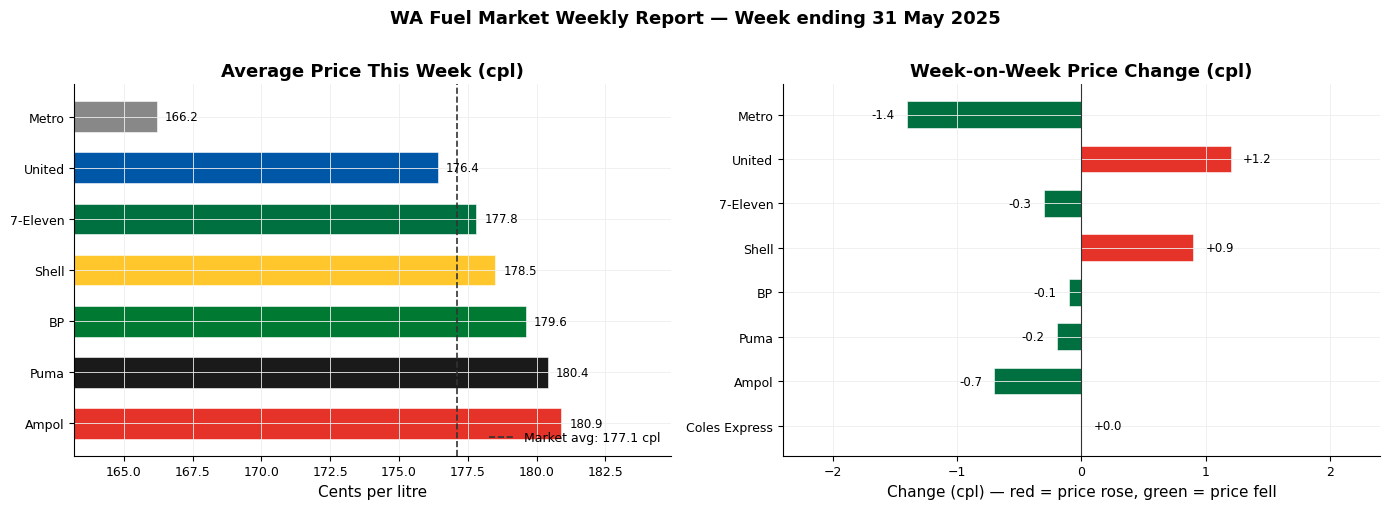

In [9]:
# Run the report for the most recent week in the dataset
latest_date = df['date'].max()
print(f"Running report for most recent week (ending {latest_date.date()})...\n")
print("=" * 65)

snapshot_latest = run_weekly_report(df, latest_date)

Running report for historical week (ending 2023-06-30)...

WEEKLY FUEL MARKET BRIEFING — Week ending 30 June 2023

MARKET OVERVIEW
------------------------------
The WA unleaded petrol market averaged 182.8 cpl this week, with a 7.9 cpl spread between the cheapest brand (Metro, 178.5 cpl) and the most expensive (Coles Express, 186.4 cpl). Prices were broadly stable week on week.

7-ELEVEN POSITION
------------------------------
7-Eleven averaged 182.3 cpl this week, ranking 3 out of 8 brands from cheapest to most expensive. This is 0.5 cpl below the market average. Week on week, 7-Eleven's price moved down by 0.3 cpl.

ANOMALY FLAGS
------------------------------
No brands are currently pricing more than 2 cpl outside their 8-week average. Market behaviour is within normal range.

FULL MARKET SNAPSHOT
------------------------------
               price_this_week  wow_change  vs_market  price_8wk_avg  deviation_from_baseline  anomaly_flag
brand                                           

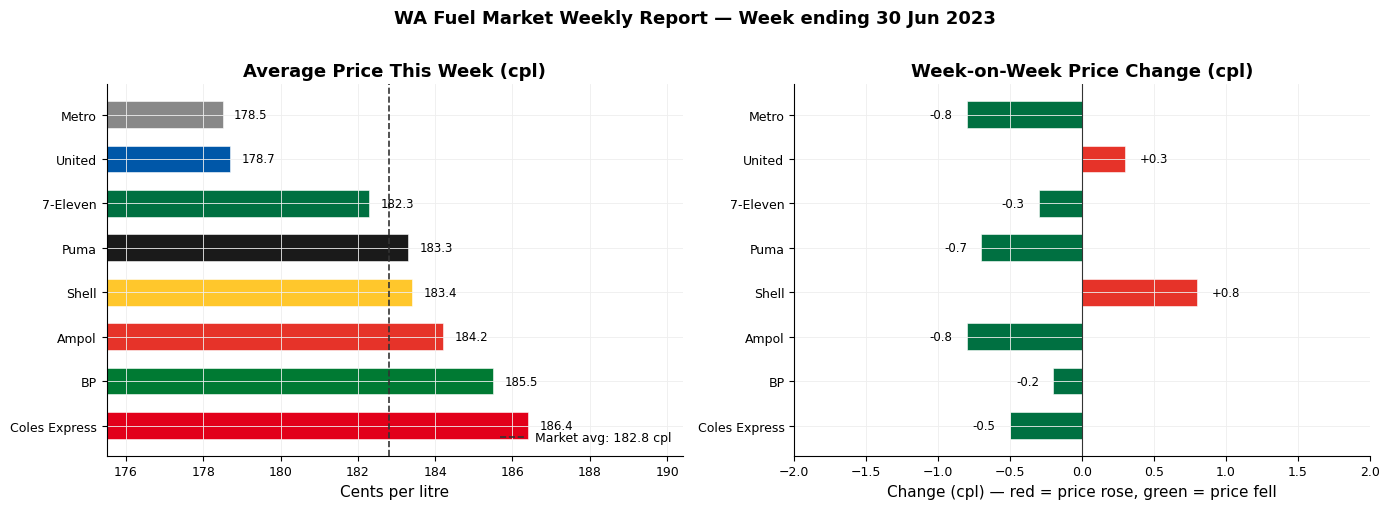

In [10]:
# Run the same report for a historical week to demonstrate repeatability
# Change this date to any week ending date within your dataset
historical_date = '2023-06-30'

print(f"Running report for historical week (ending {historical_date})...\n")
print("=" * 65)

snapshot_historical = run_weekly_report(df, historical_date)

---
## Part 3 — Trend View: 7-Eleven's Weekly Position Over Time

Running the report once is useful. Running it across every week in the dataset and plotting the outputs is more useful still — it shows how 7-Eleven's market position has shifted over time, and whether the anomaly flag would have caught any significant pricing events.

In [12]:
# Generate a snapshot for every Monday in the dataset and extract 7-Eleven's weekly metrics
# This takes 30-60 seconds to run across 3 years of weekly reports

# Get all Mondays in the dataset date range
start = df['date'].min() + timedelta(weeks=9)   # need 8 weeks of history for baseline
end   = df['date'].max()
mondays = pd.date_range(start=start, end=end, freq='W-MON')

weekly_records = []

for monday in mondays:
    try:
        snap, mkt_avg = get_weekly_snapshot(df, monday)
        if '7-Eleven' in snap.index:
            row = snap.loc['7-Eleven'].copy()
            row['report_date']  = monday
            row['market_avg']   = mkt_avg
            weekly_records.append(row)
    except Exception:
        continue

weekly_trend = pd.DataFrame(weekly_records).set_index('report_date')

print(f"Weekly trend table built: {len(weekly_trend)} weeks")
print(weekly_trend[['price_this_week', 'market_avg', 'vs_market', 'wow_change', 'anomaly_flag']].tail(8))

Weekly trend table built: 144 weeks
             price_this_week  market_avg  vs_market  wow_change  anomaly_flag
report_date                                                                  
2025-03-17             184.9       184.6        0.3        -2.1         False
2025-03-24             184.5       184.0        0.5        -0.4         False
2025-04-07             186.7       185.1        1.6         0.8         False
2025-04-21             180.5       180.5       -0.0        -4.6          True
2025-04-28             180.7       179.5        1.2         0.2          True
2025-05-12             179.2       177.5        1.7        -1.0          True
2025-05-19             178.3       175.0        3.2        -0.9          True
2025-05-26             178.0       177.2        0.8        -0.3          True


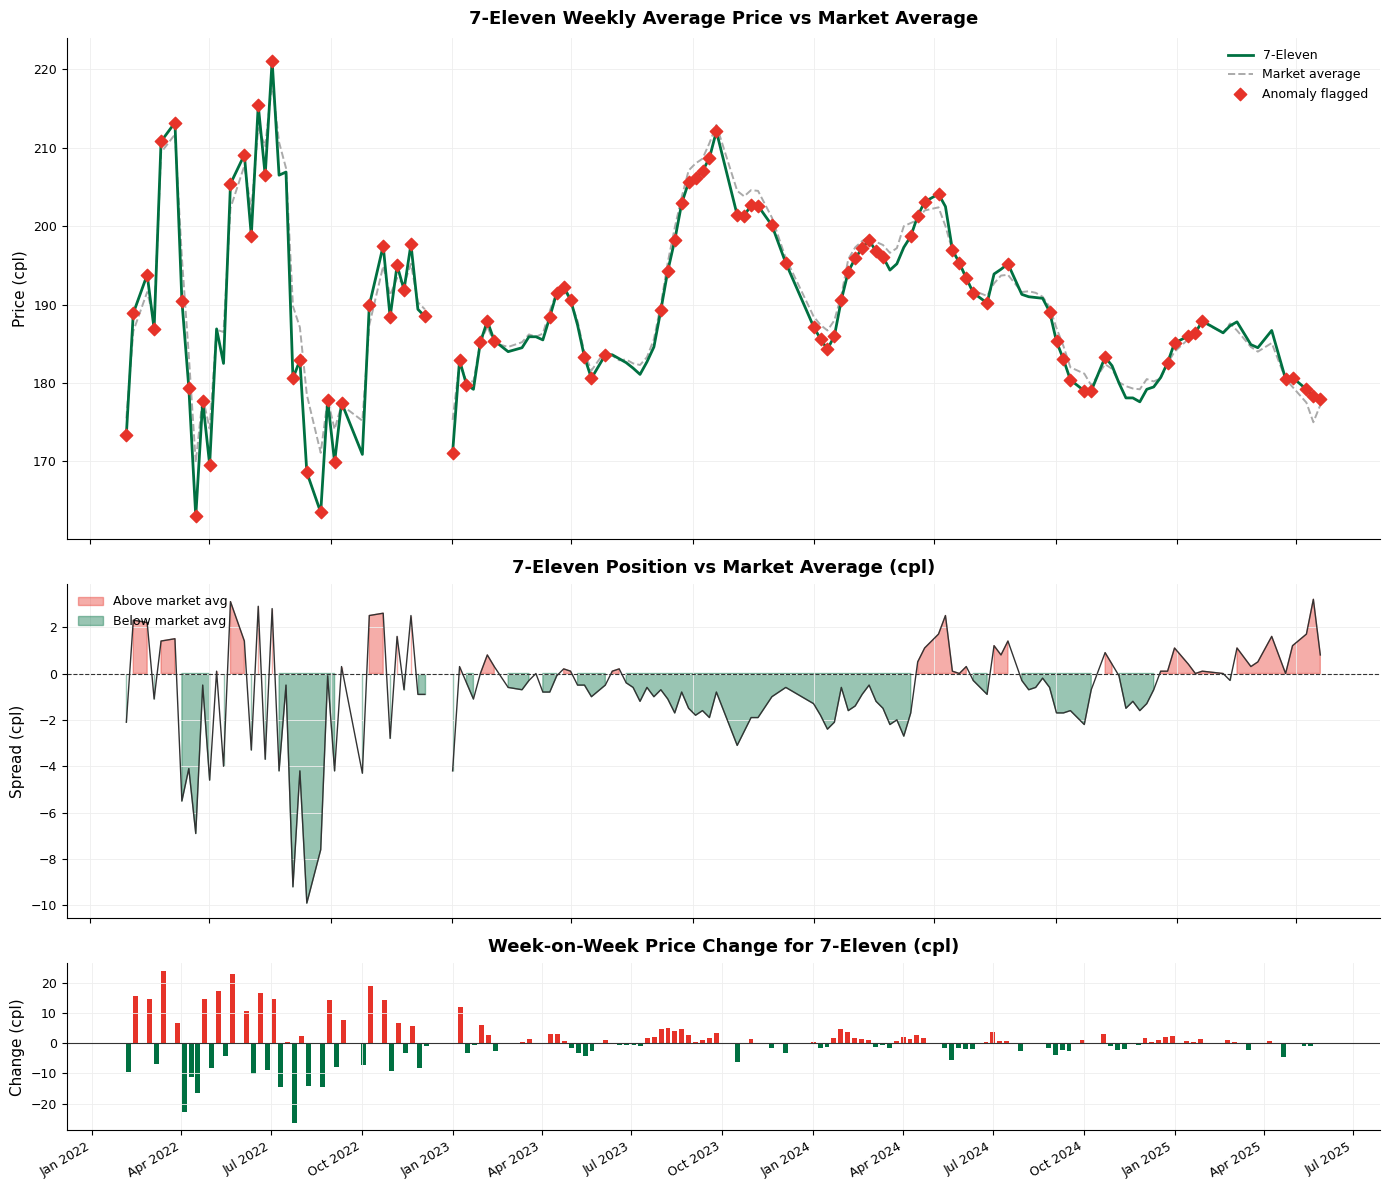

Saved to outputs/06_7eleven_weekly_trend.png


In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12),
                                      gridspec_kw={'height_ratios': [3, 2, 1]})

# Panel 1 — 7-Eleven price vs market average over time
ax1.plot(weekly_trend.index, weekly_trend['price_this_week'],
          color='#007041', linewidth=2, label='7-Eleven', zorder=4)
ax1.plot(weekly_trend.index, weekly_trend['market_avg'],
          color='#AAAAAA', linewidth=1.4, linestyle='--',
          label='Market average', zorder=3)

# Mark weeks where anomaly flag was triggered
anomaly_weeks = weekly_trend[weekly_trend['anomaly_flag'] == True]
ax1.scatter(anomaly_weeks.index, anomaly_weeks['price_this_week'],
             color='#E63329', s=40, zorder=6, label='Anomaly flagged', marker='D')

ax1.set_title('7-Eleven Weekly Average Price vs Market Average',
               fontweight='bold', pad=10)
ax1.set_ylabel('Price (cpl)')
ax1.legend()
ax1.tick_params(labelbottom=False)

# Panel 2 — vs market spread over time
ax2.fill_between(weekly_trend.index, weekly_trend['vs_market'], 0,
                   where=(weekly_trend['vs_market'] >= 0),
                   color='#E63329', alpha=0.4, label='Above market avg')
ax2.fill_between(weekly_trend.index, weekly_trend['vs_market'], 0,
                   where=(weekly_trend['vs_market'] < 0),
                   color='#007041', alpha=0.4, label='Below market avg')
ax2.plot(weekly_trend.index, weekly_trend['vs_market'],
          color='#333333', linewidth=1)
ax2.axhline(0, color='#333333', linewidth=0.8, linestyle='--')
ax2.set_title('7-Eleven Position vs Market Average (cpl)',
               fontweight='bold', pad=8)
ax2.set_ylabel('Spread (cpl)')
ax2.legend(loc='upper left')
ax2.tick_params(labelbottom=False)

# Panel 3 — week-on-week change
wow = weekly_trend['wow_change'].fillna(0)
bar_colors = ['#E63329' if v > 0 else '#007041' for v in wow]
ax3.bar(weekly_trend.index, wow, color=bar_colors,
         width=5, edgecolor='none')
ax3.axhline(0, color='#333333', linewidth=0.8)
ax3.set_title('Week-on-Week Price Change for 7-Eleven (cpl)',
               fontweight='bold', pad=8)
ax3.set_ylabel('Change (cpl)')
ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
ax3.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('outputs/06_7eleven_weekly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/06_7eleven_weekly_trend.png")

---
## Summary

This notebook has built a fully repeatable weekly fuel market reporting pipeline with three components:

**`get_weekly_snapshot(df, report_date)`** — computes each brand's current average price, week-on-week change, position vs the market average, and an anomaly flag for any brand deviating more than 2 cpl from its 8-week baseline. Accepts any date in the dataset.

**`generate_briefing_text(snapshot, market_avg, report_date)`** — converts the snapshot table into a plain-English briefing paragraph formatted for a non-technical pricing manager, including a market overview, 7-Eleven's specific position, and named anomaly flags with plain-language interpretation.

**`generate_report_chart(snapshot, market_avg, report_date)`** — produces a two-panel chart showing current prices by brand and week-on-week changes, saved to the `outputs/` folder.

Running the full report for any new week requires a single line:
```python
run_weekly_report(df, '2025-04-28')
```

The trend analysis in Part 3 shows how 7-Eleven's weekly market position has evolved across the full dataset, with anomaly flag events marked, giving a longitudinal view of pricing strategy shifts.

---
*Data source: FuelWatch Western Australia, Department of Energy, Mines, Industry Regulation and Safety.  
Licence: Creative Commons Attribution 4.0. Acknowledgement: FuelWatch (www.fuelwatch.wa.gov.au)*